In [1]:
import os
os.getcwd()

'/Users/owerko/PycharmProjects/NASA/Landsat8'

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import rasterio.mask as rmask
import fiona as fio


In [3]:
def read_landsat_images(folder_name):
    file_list = os.listdir(folder_name)
    channel_list = []
    for f in file_list:
        if (f.startswith('LC') and f.endswith('.tif')):
            if 'band' in f:
                channel_list.append(folder_name + f)
    channel_list.sort()
    channel_numbers = np.arange(1, 8)
    bands_dictionary = dict(zip(channel_numbers, channel_list))
    return bands_dictionary


In [4]:
# macOS satellite_images = read_landsat_images('/Users/tomek/OneDrive - Akademia Górniczo-Hutnicza im. Stanisława Staszica w Krakowie/Geoinformatyka/Landsat8/LC08') - przykład sciezka bezwzgledna
# satellite_images = read_landsat_images(os.getcwd()+ '/LC08') #- przykład sciezka bezwzgledna
# widows satellite_images = read_landsat_images('Landsat8\LC08') - przykład sciezka wzgledna
satellite_images = read_landsat_images('LC08')

In [5]:
for band in satellite_images:
    print(band, satellite_images[band])


1 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band1.tif
2 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band2.tif
3 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band3.tif
4 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band4.tif
5 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band5.tif
6 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band6.tif
7 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band7.tif


In [6]:
def show_band(band, color_map='gray'):
    fig = plt.figure(figsize=(8, 8))
    image_layer = plt.imshow(band)
    image_layer.set_cmap(color_map)
    plt.colorbar()
    plt.show()


def show_band2(band, color_map='gray', remove_negative=True):
    matrix = band.astype(float)
    if remove_negative:
        matrix[matrix <= 0] = np.nan
    fig = plt.figure(figsize=(8, 8))
    image_layer = plt.imshow(matrix)
    image_layer.set_cmap(color_map)
    plt.colorbar()
    # plt.savefig('plot.tif')
    plt.show()


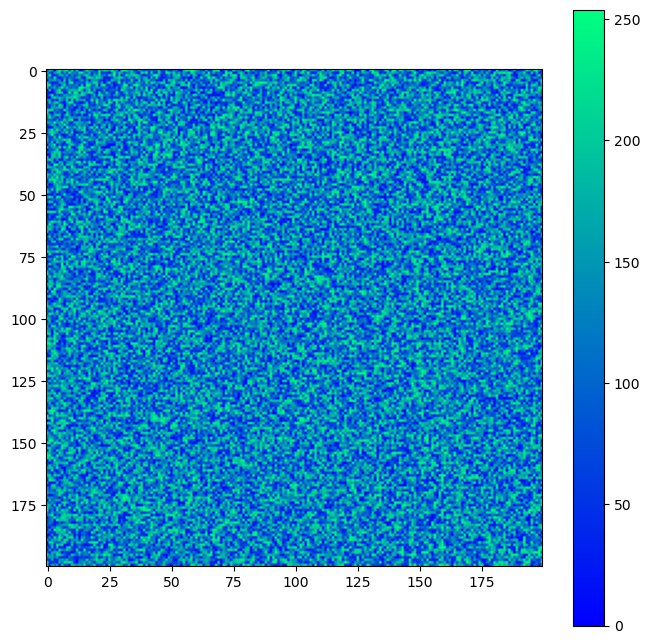

LC08/LC08_L1TP_188025_20130807_20170503_01_T1_sr_band5.tif


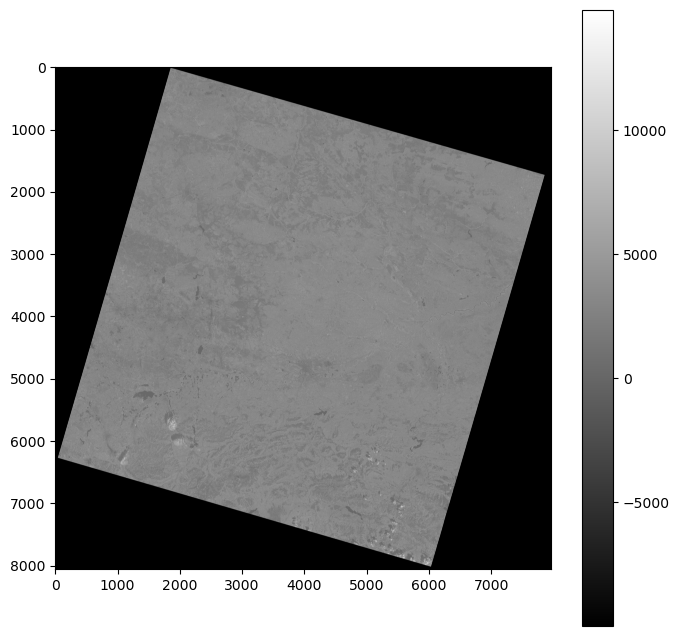

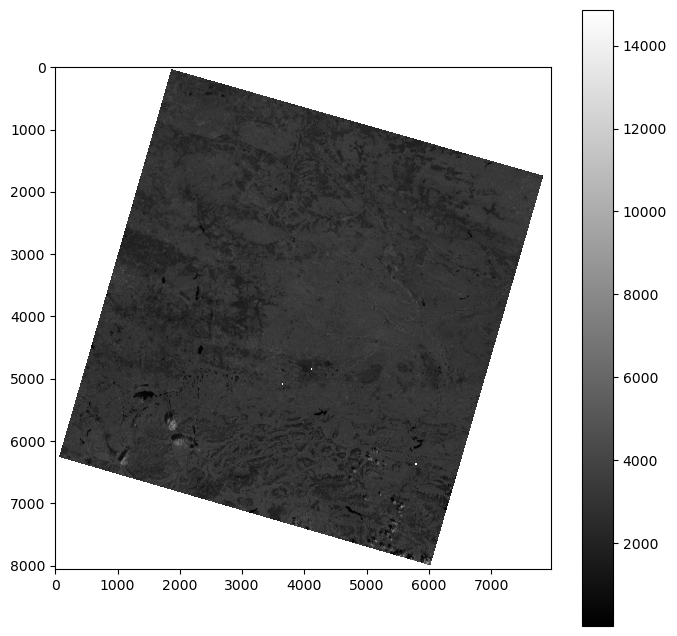

In [7]:
test = np.random.randint(low=0, high=255, size=(200, 200))
show_band(test, color_map='winter')

#band_list = read_landsat_images('/Users/tomek/OneDrive - Akademia Górniczo-Hutnicza im. Stanisława Staszica w Krakowie/Geoinformatyka/Landsat8/LC08/')
band_list = read_landsat_images('LC08/')
print(band_list[5])

with rio.open(band_list[5], 'r') as src:
    band_matrix = src.read(1)

show_band(band_matrix)
show_band2(band_matrix)

